# Inferring $\Lambda$CDM from the CMB with Markov Chain Monte Carlo

In this tutorial we learn the **fundamentals of Markov Chain Monte Carlo (MCMC)** on a
real cosmological inference problem: measuring the parameters of the $\Lambda$CDM model
from the Planck satellite's CMB **temperature** power spectrum.

### The inference problem

We have data $\mathbf{d}$ (the measured TT power spectrum) and a model that predicts the
spectrum from a handful of cosmological parameters $\boldsymbol\theta$. Bayes' theorem
tells us how to update our knowledge of $\boldsymbol\theta$ given the data:

$$ \underbrace{p(\boldsymbol\theta\,|\,\mathbf{d})}_{\text{posterior}}
   \;\propto\;
   \underbrace{p(\mathbf{d}\,|\,\boldsymbol\theta)}_{\text{likelihood}}\;
   \underbrace{p(\boldsymbol\theta)}_{\text{prior}} . $$

The posterior is a probability distribution over a 5-dimensional parameter space. We
cannot write it down in closed form, and gridding 5 dimensions is hopelessly expensive.
Instead we **draw samples** from it with MCMC: a random walk whose stationary distribution
*is* the posterior. Histogramming the samples then gives us marginal distributions, means,
error bars and correlations.

### Our model

We sample five parameters:

| symbol | meaning |
|---|---|
| $\omega_b=\Omega_b h^2$ | physical baryon density |
| $\omega_c=\Omega_c h^2$ | physical cold dark matter density |
| $h$ | Hubble constant $H_0/100$ |
| $n_s$ | scalar spectral index |
| $A\equiv\ln\!\big(10^{10}A_s\,e^{-2\tau}\big)$ | **a single amplitude parameter** |

Why combine the amplitude $A_s$ and the optical depth to reionization $\tau$ into one
number? The primary TT spectrum at the scales Planck measures best ($\ell\gtrsim 30$) only
constrains the product $A_s\,e^{-2\tau}$ — raising $A_s$ and raising $\tau$ in the right
ratio leaves the spectrum unchanged. Breaking that degeneracy needs large-scale
*polarization*, which we are not using here. So we fix $\tau$ to a reference value and let
the combination $A$ float; the constraint we obtain should be read as a constraint on
$A_s e^{-2\tau}$.

We will:
1. build a fast **theory** prediction with a pretrained neural-network emulator,
2. attach a realistic **Planck likelihood**,
3. write a **Metropolis-Hastings** sampler,
4. use a short **pilot run** to learn a good proposal distribution,
5. do a **main run**, check convergence, and look at the posterior.

The whole notebook runs in a few minutes.

## 1. Setup

Run this cell to install basic dependencies.
It also fetches the [Planck `plik-lite` likelihood code](https://github.com/heatherprince/planck-lite-py) and a
small pretrained emulator file from [CosmoPower](https://alessiospuriomancini.github.io/cosmopower/).

In [1]:
!test -d planck-lite-py || git clone -q https://github.com/heatherprince/planck-lite-py

import os, sys, pickle, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

EMULATOR_FILE = 'cmb_TT_NN.pkl'
if not os.path.exists(EMULATOR_FILE):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/alessiospuriomancini/cosmopower/'
        'main/cosmopower/trained_models/CP_paper/CMB/cmb_TT_NN.pkl', EMULATOR_FILE)

sys.path.insert(0, 'planck-lite-py')
from planck_lite_py import PlanckLitePy
np.random.seed(0)

## 2. The theory: predicting the CMB spectrum

To test a cosmology against the data we need its predicted TT spectrum. A Boltzmann code
(CAMB/CLASS) takes seconds per evaluation — too slow for this exercise — so we use a **pretrained
neural-network emulator** ([CosmoPower](https://arxiv.org/abs/2106.03846)) that returns the
spectrum in under a millisecond.

The next cell loads it and gives us the one function we actually use:
**`theory_Dl(params)`**, which maps our five parameters to the temperature power spectrum
$D_\ell^{TT}=\ell(\ell+1)C_\ell/2\pi$ in $\mu K^2$.

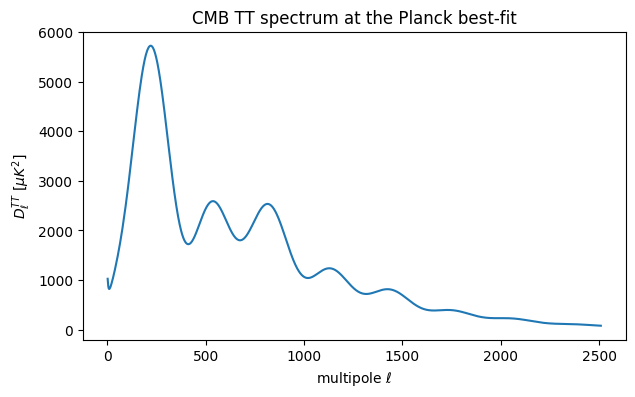

In [2]:
# --- load the emulator (a few matrix multiplications; details not important here) ------
class _ListShim(list):
    def __setstate__(self, state): pass

class _NoTFUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if name == 'ListWrapper' or 'tracking' in module or 'trackable' in module:
            return _ListShim
        return super().find_class(module, name)

def load_emulator(filename):
    with open(filename, 'rb') as f:
        (W, b, alphas, betas, par_mean, par_std, feat_mean, feat_std,
         n_par, parameters, n_modes, modes, n_hidden, n_layers, arch
         ) = _NoTFUnpickler(f).load()
    return dict(W=[np.asarray(w) for w in W],   b=[np.asarray(x) for x in b],
                alphas=[np.asarray(x) for x in alphas], betas=[np.asarray(x) for x in betas],
                par_mean=np.asarray(par_mean),  par_std=np.asarray(par_std),
                feat_mean=np.asarray(feat_mean), feat_std=np.asarray(feat_std),
                parameters=list(parameters), modes=np.asarray(modes), n_layers=int(n_layers))

def emulate_Cl(emu, params):
    x = np.stack([np.atleast_1d(np.asarray(params[k], float)) for k in emu['parameters']], axis=1)
    h = (x - emu['par_mean']) / emu['par_std']
    for i in range(emu['n_layers'] - 1):
        a = h @ emu['W'][i] + emu['b'][i]
        h = (emu['betas'][i] + (1. - emu['betas'][i])/(1. + np.exp(-emu['alphas'][i]*a))) * a
    return 10**((h @ emu['W'][-1] + emu['b'][-1]) * emu['feat_std'] + emu['feat_mean'])
# --------------------------------------------------------------------------------------

emu     = load_emulator(EMULATOR_FILE)
ell     = emu['modes']      # multipoles, 2 ... 2508
T_CMB   = 2.7255e6          # CMB temperature in micro-Kelvin
TAU_REF = 0.0544            # fixed optical depth to reionization

PARAM_NAMES  = ['omega_b', 'omega_cdm', 'h', 'n_s', 'A']
PARAM_LABELS = [r'$\omega_b$', r'$\omega_c$', r'$h$', r'$n_s$',
                r'$A=\ln(10^{10}A_s e^{-2\tau})$']

def theory_Dl(p):
    '''TT power spectrum D_ell = l(l+1)C_l/2pi in microK^2 for the 5 sampled parameters.'''
    omega_b, omega_cdm, h, n_s, A = p
    params = {'omega_b': omega_b, 'omega_cdm': omega_cdm, 'h': h,
              'tau_reio': TAU_REF, 'n_s': n_s, 'ln10^{10}A_s': A + 2*TAU_REF}
    Cl = emulate_Cl(emu, params)[0]
    return ell*(ell+1)/(2*np.pi) * Cl * T_CMB**2

# Planck 2018 best-fit values (A built from ln10As=3.044 and TAU_REF)
PLANCK = np.array([0.02237, 0.1200, 0.6736, 0.9649, 3.044 - 2*TAU_REF])

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(ell, theory_Dl(PLANCK))
ax.set_xlabel(r'multipole $\ell$'); ax.set_ylabel(r'$D_\ell^{TT}\ [\mu K^2]$')
ax.set_title('CMB TT spectrum at the Planck best-fit')
plt.show()

The first acoustic peak sits at $\ell\approx220$ with $D_\ell\approx5700\,\mu K^2$ —
exactly the famous Planck TT spectrum. Our theory prediction works.

## 3. The likelihood: Planck `plik-lite` (TT)

`plik-lite` is the *foreground-marginalised* Planck high-$\ell$ likelihood. The
nuisance parameters describing foregrounds have already been marginalised out, leaving a
clean compressed data vector of **215 binned bandpowers** over $30\le\ell\le2508$ with a
**band-power covariance matrix** $\mathsf{C}$. The likelihood is Gaussian,

$$ \ln\mathcal{L}(\boldsymbol\theta) = -\tfrac12\,
   \big[\mathbf{d}-\mathbf{t}(\boldsymbol\theta)\big]^{\!\top}\,
   \mathsf{C}^{-1}\,
   \big[\mathbf{d}-\mathbf{t}(\boldsymbol\theta)\big], $$

where $\mathbf{t}(\boldsymbol\theta)$ is our theory spectrum binned the same way as the
data. There are **no free nuisance parameters** (the absolute calibration is fixed), so the
likelihood is purely a function of our five cosmological parameters. The `planck-lite-py`
object does the binning and the linear algebra for us; we just hand it the theory $D_\ell$
starting at $\ell=2$.

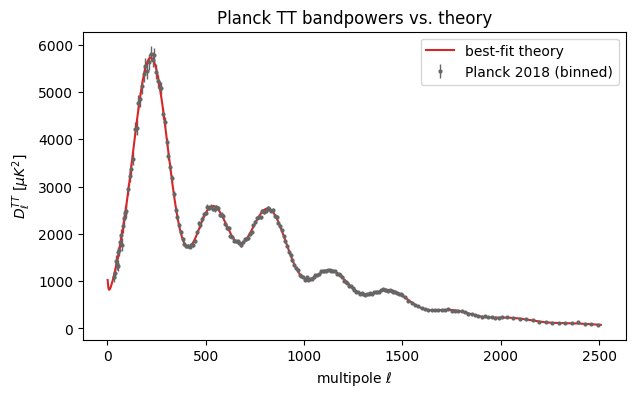

log-likelihood at the Planck best-fit: -111.89644780854171
chi^2 = 223.79289561708342 for 215 bandpowers


In [3]:
likelihood = PlanckLitePy(data_directory='planck-lite-py/data',
                          year=2018, spectra='TT', use_low_ell_bins=False)
_zero = np.zeros(len(ell))   # placeholder for the TE/EE slots we are not using

def log_like(p):
    return likelihood.loglike(theory_Dl(p), _zero, _zero, ellmin=int(ell[0]))

# the binned data and errors live inside the likelihood object; convert C_l -> D_l
nbin = likelihood.nbintt
bl   = likelihood.bval[:nbin]
binfac  = bl*(bl+1)/(2*np.pi)
Dl_data = binfac * likelihood.X_data[:nbin]
Dl_err  = binfac * likelihood.X_sig[:nbin]

fig, ax = plt.subplots(figsize=(7,4))
ax.errorbar(bl, Dl_data, yerr=Dl_err, fmt='.', ms=4, lw=1, color='0.4',
            label='Planck 2018 (binned)')
ax.plot(ell, theory_Dl(PLANCK), 'C3', label='best-fit theory')
ax.set_xlabel(r'multipole $\ell$'); ax.set_ylabel(r'$D_\ell^{TT}\ [\mu K^2]$')
ax.legend(); ax.set_title('Planck TT bandpowers vs. theory')
plt.show()

print('log-likelihood at the Planck best-fit:', log_like(PLANCK))
print('chi^2 =', -2*log_like(PLANCK), 'for', nbin, 'bandpowers')

## 4. Priors and the posterior

We adopt **flat (uniform) priors** over generous ranges that comfortably contain the
posterior and stay within the region where the emulator was trained. The log-posterior is
then just `log_prior + log_like`, returning $-\infty$ outside the prior box so the sampler
never steps there.

In [4]:
PRIOR_LO = np.array([0.019, 0.090, 0.60, 0.90, 2.80])
PRIOR_HI = np.array([0.025, 0.150, 0.75, 1.02, 3.10])

def log_prior(p):
    if np.all(p >= PRIOR_LO) and np.all(p <= PRIOR_HI):
        return 0.0
    return -np.inf

def log_posterior(p):
    lp = log_prior(p)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_like(p)

## 5. Metropolis-Hastings

The Metropolis-Hastings algorithm builds the chain one step at a time. Suppose the chain is
currently at $\boldsymbol\theta$. We

1. **propose** a new point $\boldsymbol\theta'$ by drawing from a *proposal distribution*
   $q(\boldsymbol\theta'\,|\,\boldsymbol\theta)$ — here a Gaussian centred on the current
   point,
2. compute the **acceptance probability**
   $$ \alpha = \min\left(1,
      \frac{p(\boldsymbol\theta'|\mathbf d) q(\boldsymbol\theta|\boldsymbol\theta')}
           {p(\boldsymbol\theta|\mathbf d) q(\boldsymbol\theta'|\boldsymbol\theta)}\right), $$
3. draw $u\sim\mathcal U(0,1)$ and **accept** the move (set the next state to
   $\boldsymbol\theta'$) if $u<\alpha$, otherwise **reject** it and the next state is again
   $\boldsymbol\theta$.

The proposal ratio (the $q$'s) cancels and $\alpha$ reduces
to the ratio of posteriors. **Why is this true?**

Working with log-probabilities, we accept when
$$ \ln u \;<\; \ln p(\boldsymbol\theta'|\mathbf d) - \ln p(\boldsymbol\theta|\mathbf d). $$

Note that rejected steps are **not** discarded — the chain repeats its current state. That
repetition is what makes the samples land in proportion to the posterior density.

> ### ✏️ Exercise
> The next cell implements a single Metropolis-Hastings transition. **Try to write it
> yourself**: given the current state, its log-posterior, and the Cholesky factor of the
> proposal covariance, draw a proposal, decide whether to accept it, and return the next
> state. The driver loop and everything downstream is provided for you.

In [5]:
# ===========================================================================
# EXERCISE CELL  --  delete the body between the markers and fill it in yourself
# ---------------------------------------------------------------------------
def mh_step(x, log_p, prop_chol):
    '''Perform one Metropolis-Hastings transition.

    Parameters
    ----------
    x         : current position in parameter space (array of 5 numbers)
    log_p     : log-posterior already evaluated at x  (so we don't recompute it)
    prop_chol : Cholesky factor L of the proposal covariance;
                a proposal is x' = x + L @ z  with  z ~ N(0, I)

    Returns
    -------
    (x_next, log_p_next, accepted)
    '''
    # ----------------------------- BEGIN SOLUTION --------------------------
    # 1. propose a new point from the (symmetric) Gaussian proposal
    proposal = x + prop_chol @ np.random.standard_normal(len(x))

    # 2. evaluate the log-posterior there
    log_p_prop = log_posterior(proposal)

    # 3. Metropolis acceptance test (symmetric proposal -> ratio = posterior ratio)
    if np.log(np.random.random()) < log_p_prop - log_p:
        return proposal, log_p_prop, True    # accept: move to the proposal
    else:
        return x, log_p, False               # reject: stay put
    # ------------------------------ END SOLUTION ---------------------------
# ===========================================================================

## 6. The sampler driver

This loop simply calls `mh_step` repeatedly, storing the visited points and their
log-posteriors, and reports the fraction of accepted moves (the **acceptance rate**).

In [6]:
def run_chain(start, prop_chol, n_steps):
    x = np.array(start, dtype=float)
    log_p = log_posterior(x)
    chain   = np.empty((n_steps, len(x)))
    log_ps  = np.empty(n_steps)
    n_accept = 0
    for i in tqdm(range(n_steps)):
        x, log_p, accepted = mh_step(x, log_p, prop_chol)
        chain[i]  = x
        log_ps[i] = log_p
        n_accept += accepted
    print(f'acceptance rate: {n_accept/n_steps:.2f}')
    return chain, log_ps

## 7. Pilot run: learning the proposal

The efficiency of Metropolis-Hastings depends entirely on the **proposal distribution**. If
the proposal steps are too large almost every move is rejected; if they are too small the
chain crawls and explores slowly. Worse, our parameters are strongly **correlated** in the
posterior, so a good proposal must step along the correlated directions, not along the
coordinate axes.

We don't know those correlations in advance, so we use a two-stage trick:

1. a short **pilot run** with a crude *diagonal* proposal (hand-guessed step sizes), just
   to get a rough idea of where the posterior is and how the parameters scatter;
2. estimate the **parameter covariance** from the pilot samples and use it to build a much
   better proposal for the main run.

Let's run the pilot, starting from a reasonable initial guess.

100%|██████████| 2500/2500 [00:33<00:00, 74.02it/s]


acceptance rate: 0.24


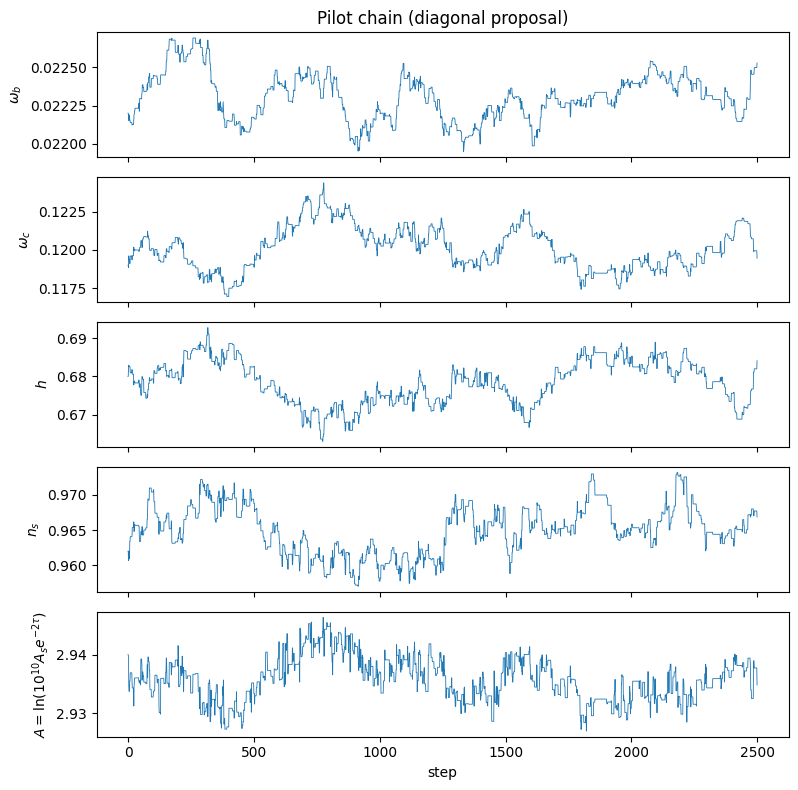

In [7]:
start_guess = np.array([0.0222, 0.119, 0.680, 0.962, 2.940])
pilot_steps = np.array([4e-5, 4e-4, 2e-3, 1.2e-3, 4e-3])   # rough per-parameter guesses

np.random.seed(1)
pilot_chain, pilot_logp = run_chain(start_guess, np.diag(pilot_steps), 2500)

fig, axes = plt.subplots(5, 1, figsize=(8, 8), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(pilot_chain[:, i], lw=0.6)
    ax.set_ylabel(PARAM_LABELS[i])
axes[-1].set_xlabel('step'); axes[0].set_title('Pilot chain (diagonal proposal)')
plt.tight_layout(); plt.show()

The pilot mixes only sluggishly — you can see it wandering slowly because the
diagonal proposal ignores the parameter correlations. That is fine: all we need from it is
a rough covariance.

## 8. Estimating the proposal covariance

We discard the first part of the pilot as **burn-in** (the chain had not yet reached the
bulk of the posterior) and estimate the covariance of the remaining samples. A standard
result (Gelman, Roberts & Gilks) is that for a $d$-dimensional target the optimal Gaussian
proposal is the posterior covariance scaled by $2.38/\sqrt{d}$; this gives an acceptance
rate near the efficient $\sim$0.234. We pass the Cholesky factor of that scaled covariance
to the sampler.

In [8]:
pilot_burn = 500
cov = np.cov(pilot_chain[pilot_burn:].T)
prop_chol = np.linalg.cholesky(cov) * 2.38 / np.sqrt(len(start_guess))

print('estimated parameter standard deviations from the pilot:')
for nm, s in zip(PARAM_NAMES, np.sqrt(np.diag(cov))):
    print(f'  {nm:10s} {s:.5f}')

estimated parameter standard deviations from the pilot:
  omega_b    0.00013
  omega_cdm  0.00136
  h          0.00545
  n_s        0.00336
  A          0.00369


## 9. Main run

Now we run a longer chain with the tuned proposal. We deliberately **start it off to one
side** of the posterior so you can watch the chain "burn in" — march to the high-probability
region — before settling down to sample it.

In [9]:
start_main = np.array([0.0231, 0.115, 0.690, 0.945, 2.915])  # a few-sigma off on purpose

np.random.seed(2)
chain, log_ps = run_chain(start_main, prop_chol, 25000)

100%|██████████| 25000/25000 [05:23<00:00, 77.32it/s]

acceptance rate: 0.36


## 10. Diagnostics

**Burn-in.** Plot the log-posterior versus step: it climbs from the poor starting point and
then fluctuates around a stable level. Everything before it stabilises must be discarded.

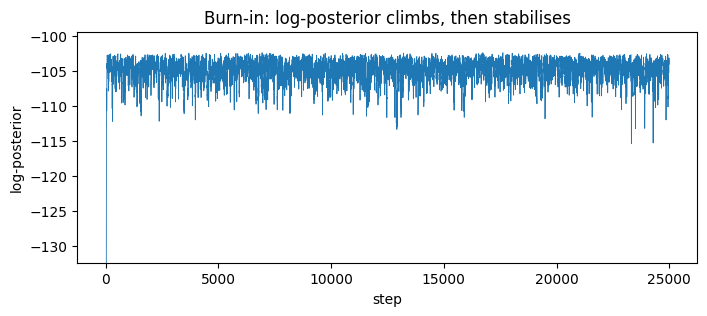

In [10]:
fig, ax = plt.subplots(figsize=(8,3))
ax.plot(log_ps, lw=0.6)
ax.set_xlabel('step'); ax.set_ylabel('log-posterior')
ax.set_ylim(log_ps.max()-30, log_ps.max()+3)
ax.set_title('Burn-in: log-posterior climbs, then stabilises')
plt.show()

The chain reaches the typical set within a few hundred steps. We conservatively
discard the first 2000 as burn-in.

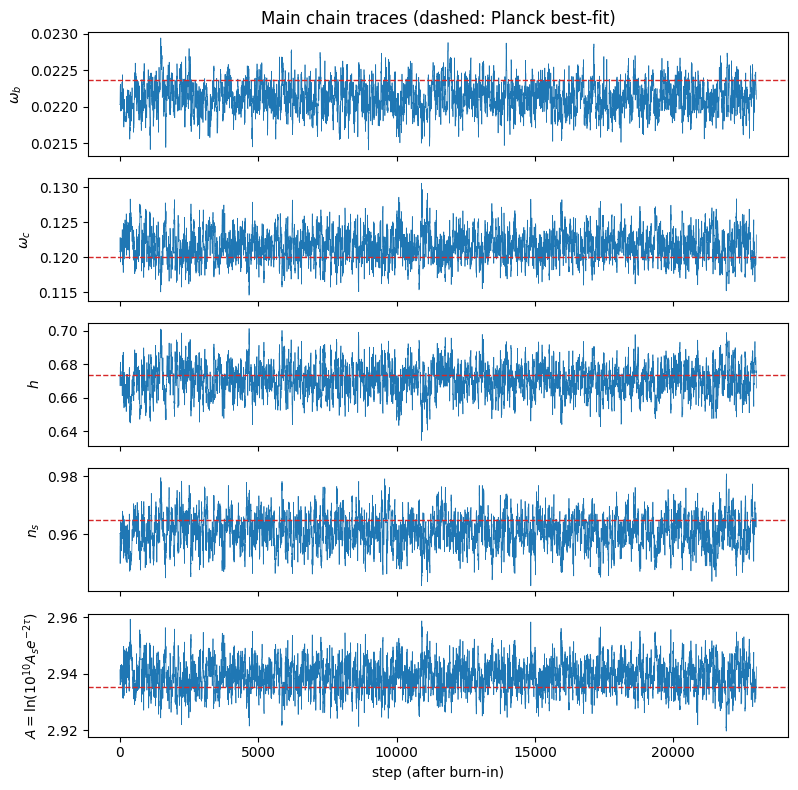

In [11]:
burn = 2000
samples = chain[burn:]

fig, axes = plt.subplots(5, 1, figsize=(8, 8), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(samples[:, i], lw=0.5)
    ax.axhline(PLANCK[i], color='C3', lw=1, ls='--')
    ax.set_ylabel(PARAM_LABELS[i])
axes[-1].set_xlabel('step (after burn-in)')
axes[0].set_title('Main chain traces (dashed: Planck best-fit)')
plt.tight_layout(); plt.show()

**Autocorrelation and effective sample size.** Successive MCMC samples are
correlated. The *integrated autocorrelation time* $\tau_{\rm int}$ tells us roughly how many
steps separate independent samples; the **effective sample size** is
$N_{\rm eff}\approx N/\tau_{\rm int}$.

In [12]:
def autocorr_time(x):
    x = x - x.mean()
    n = len(x)
    f = np.fft.fft(x, 2*n)
    acf = np.fft.ifft(f*np.conj(f))[:n].real
    acf /= acf[0]
    # Sokal's automatic windowing
    tau = 1 + 2*np.cumsum(acf[1:])
    window = np.arange(1, n)
    m = window >= 6*tau
    c = window[m][0] if m.any() else n-1
    return tau[c-1]

print(f'{"parameter":12s} {"tau_int":>8s} {"N_eff":>8s}')
for i, nm in enumerate(PARAM_NAMES):
    t = autocorr_time(samples[:, i])
    print(f'{nm:12s} {t:8.1f} {len(samples)/t:8.0f}')

parameter     tau_int    N_eff
omega_b          39.0      589
omega_cdm        28.6      805
h                31.6      728
n_s              34.4      668
A                26.6      864


## 11. The posterior

Finally, the payoff: the marginal distributions and their correlations, shown as a
**triangle (corner) plot**. The diagonal panels are the 1-D marginal posteriors of each
parameter; the off-diagonal panels show the joint 2-D posteriors with 68% and 95% credible
contours. Dashed lines mark the Planck 2018 best-fit values.

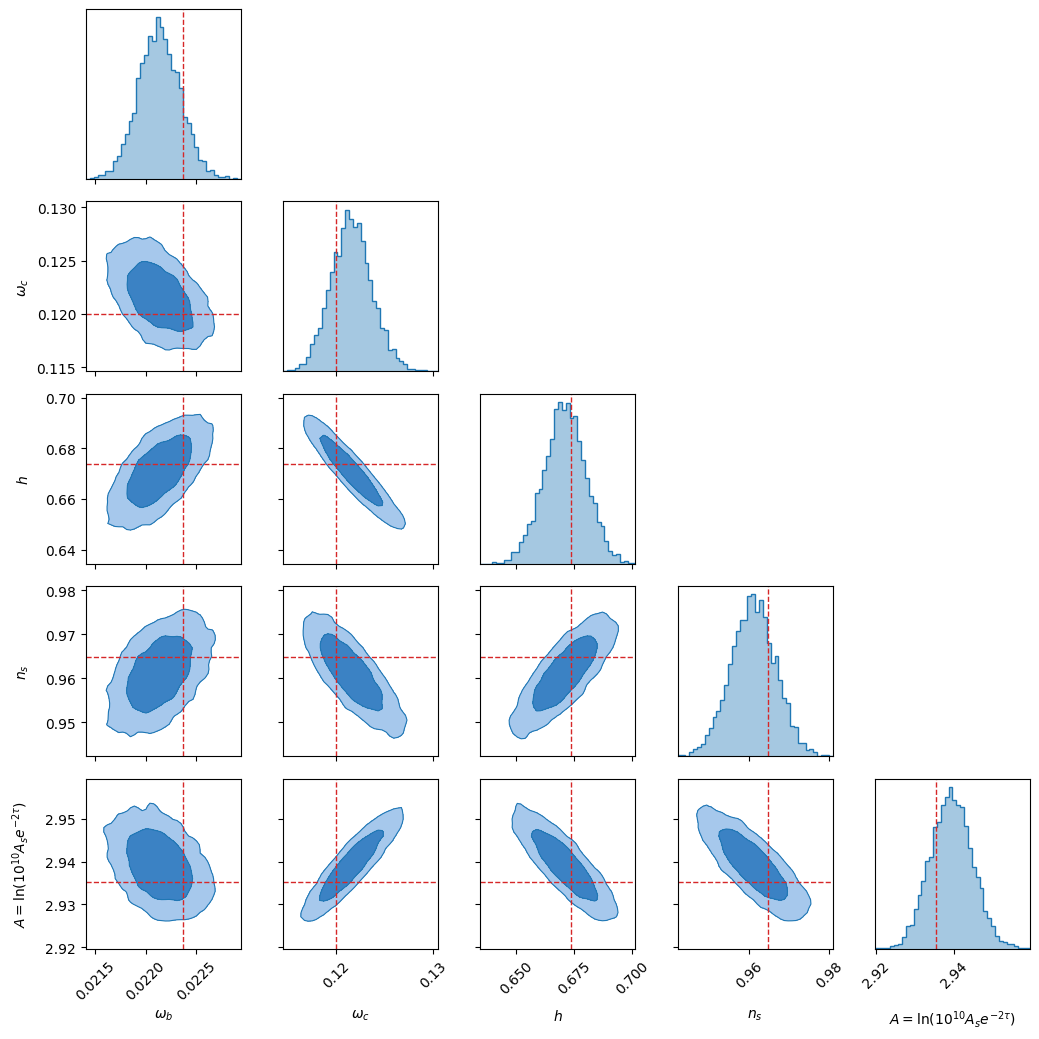

In [13]:
from scipy.ndimage import gaussian_filter

def corner_plot(samples, labels, truths=None, bins=40, smooth=1.0):
    d = samples.shape[1]
    fig, axes = plt.subplots(d, d, figsize=(2.1*d, 2.1*d))
    lims = [(samples[:,k].min(), samples[:,k].max()) for k in range(d)]
    for i in range(d):
        for j in range(d):
            ax = axes[i, j]
            if j > i:
                ax.axis('off'); continue
            if i == j:
                ax.hist(samples[:, i], bins=bins, range=lims[i],
                        color='C0', histtype='stepfilled', alpha=0.4, density=True)
                ax.hist(samples[:, i], bins=bins, range=lims[i],
                        color='C0', histtype='step', density=True)
                if truths is not None:
                    ax.axvline(truths[i], color='C3', ls='--', lw=1)
                ax.set_yticks([]); ax.set_xlim(*lims[i])
            else:
                H, xe, ye = np.histogram2d(samples[:, j], samples[:, i], bins=bins,
                                           range=[lims[j], lims[i]])
                H = gaussian_filter(H, smooth)
                flat = np.sort(H.ravel())[::-1]
                csum = np.cumsum(flat); csum /= csum[-1]
                t68 = flat[np.searchsorted(csum, 0.68)]
                t95 = flat[np.searchsorted(csum, 0.95)]
                xc = 0.5*(xe[:-1]+xe[1:]); yc = 0.5*(ye[:-1]+ye[1:])
                ax.contourf(xc, yc, H.T, levels=[t95, t68, H.max()],
                            colors=['#a6c8ec', '#3b82c4'])
                ax.contour(xc, yc, H.T, levels=[t95, t68], colors='C0', linewidths=0.8)
                if truths is not None:
                    ax.axvline(truths[j], color='C3', ls='--', lw=1)
                    ax.axhline(truths[i], color='C3', ls='--', lw=1)
                ax.set_xlim(*lims[j]); ax.set_ylim(*lims[i])
            if i == d-1:
                ax.set_xlabel(labels[j]); ax.tick_params(axis='x', rotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0 and i != 0:
                ax.set_ylabel(labels[i])
            else:
                ax.set_yticklabels([])
    fig.align_labels()
    plt.tight_layout()
    return fig

corner_plot(samples, PARAM_LABELS, truths=PLANCK)
plt.show()

In [14]:
print(f'{"parameter":28s} {"posterior mean +/- std":28s} {"Planck 2018":>12s}')
for i, lab in enumerate(['omega_b','omega_c','h','n_s','A = ln(1e10 As e^-2tau)']):
    m, s = samples[:, i].mean(), samples[:, i].std()
    print(f'{lab:28s} {m:10.5f} +/- {s:8.5f}      {PLANCK[i]:12.5f}'
          f'   ({(m-PLANCK[i])/s:+.1f} sigma)')

parameter                    posterior mean +/- std        Planck 2018
omega_b                         0.02213 +/-  0.00021           0.02237   (-1.1 sigma)
omega_c                         0.12163 +/-  0.00212           0.12000   (+0.8 sigma)
h                               0.67084 +/-  0.00914           0.67360   (-0.3 sigma)
n_s                             0.96106 +/-  0.00561           0.96490   (-0.7 sigma)
A = ln(1e10 As e^-2tau)         2.93921 +/-  0.00539           2.93520   (+0.7 sigma)


Every parameter is recovered within about $1\sigma$ of the Planck values, from the
real Planck TT data — using a sampler we wrote in a few lines. You can also see the
characteristic $\Lambda$CDM degeneracies in the contours (for example the positive
$\omega_c$–$h$ correlation along the line of constant peak positions).